In [ ]:
# Latent rollout + reconstruction from a start observation and action sequence
import torch


def rollout_latent_and_recon(
    wm,
    obs_batch,
    actions,
    start_t=0,
    deterministic=True,
    use_soft_stoch=True,
):
    """
    obs_batch: dict with keys like state/image/action/is_first (B,T,...)
    actions: tensor (B, H, action_dim) for rollout
    start_t: index into obs_batch to initialize posterior state
    """
    data = wm.preprocess(obs_batch)
    embed = wm.encoder(data)
    post, _ = wm.dynamics.observe(embed, data["action"], data["is_first"])
    state = {k: v[:, start_t] for k, v in post.items()}

    feats = []
    recons = {}

    def _feat_and_recon(cur_state):
        if use_soft_stoch and "logit" in cur_state:
            probs = torch.softmax(cur_state["logit"], dim=-1)
            cur_state = {**cur_state, "stoch": probs}
        feat = wm.dynamics.get_feat(cur_state)
        dists = wm.heads["decoder"](feat)
        recon = {k: v.mode() for k, v in dists.items()}
        return feat, recon

    feat0, recon0 = _feat_and_recon(state)
    feats.append(feat0)
    for k, v in recon0.items():
        recons.setdefault(k, []).append(v)

    for t in range(actions.shape[1]):
        state = wm.dynamics.img_step(state,
                                     actions[:, t],
                                     sample=not deterministic)
        feat_t, recon_t = _feat_and_recon(state)
        feats.append(feat_t)
        for k, v in recon_t.items():
            recons.setdefault(k, []).append(v)

    feats = torch.stack(feats, dim=1)  # (B, H+1, feat_dim)
    recons = {k: torch.stack(v, dim=1) for k, v in recons.items()}
    return feats, recons


# Example usage:
# feats_roll, recons_roll = rollout_latent_and_recon(wm, obs_batch, actions)
# print(feats_roll.shape, {k: v.shape for k, v in recons_roll.items()})


In [ ]:
import os

os.environ["MUJOCO_GL"] = "egl"

In [2]:
import numpy as np

In [3]:
import argparse
import pathlib
import sys

import numpy as np
import torch
#from omegaconf import OmegaConf

import sys

sys.path.append("/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch")
import dreamer as dreamer_main
import models as dreamer_models
import tools as dreamer_tools
import ruamel.yaml as yaml


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [6]:
# Real Dreamer obs_batch from DMC cartpole_swingup (vision + proprio)
import numpy as np
import torch

from envs import dmc
import envs.wrappers as wrappers

T = 10  # rollout length

# Create env (matches Dreamer DMC defaults)
env = dmc.DeepMindControl("cartpole_swingup",
                          action_repeat=1,
                          size=(64, 64),
                          seed=0)
env = wrappers.NormalizeActions(env)

obs_list = []
action_list = []
reward_list = [0.0]
discount_list = [1.0]

obs = env.reset()
obs_list.append(obs)

for _ in range(T - 1):
    action = env.action_space.sample()
    next_obs, reward, done, info = env.step(action)
    action_list.append(action)
    reward_list.append(reward)
    discount_list.append(float(info.get("discount", 1.0)))
    obs_list.append(next_obs)
    if done:
        break

# Build obs_batch with batch dimension
obs_batch = {}
for key in obs_list[0].keys():
    obs_batch[key] = np.stack([o[key] for o in obs_list], axis=0)[None, ...]

# Actions: zero for t=0, then executed actions
action_dim = env.action_space.shape[0]
actions = np.zeros((len(obs_list), action_dim), dtype=np.float32)
if action_list:
    actions[1:1 + len(action_list)] = np.stack(action_list, axis=0)
obs_batch["action"] = actions[None, ...]

# Rewards/discounts aligned with obs_list
obs_batch["reward"] = np.array(reward_list, dtype=np.float32)[None, ...]
obs_batch["discount"] = np.array(discount_list, dtype=np.float32)[None, ...]

# Use the same actions downstream for rollouts
actions = obs_batch["action"]


In [8]:
obs_batch.keys()

dict_keys(['position', 'velocity', 'image', 'is_terminal', 'is_first', 'action', 'reward', 'discount'])

In [5]:
plt.imshow(next_obs['image'])

NameError: name 'plt' is not defined

In [53]:
obs_batch['position'].shape

(1, 10, 3)

In [9]:
obs_space = env.observation_space

In [ ]:
def _parse_dreamer_config(configs_path, config_names, overrides):
    configs = yaml.safe_load(pathlib.Path(configs_path).read_text())

    def recursive_update(base, update):
        for key, value in update.items():
            if isinstance(value, dict) and key in base:
                recursive_update(base[key], value)
            else:
                base[key] = value

    name_list = ["defaults", *config_names] if config_names else ["defaults"]
    defaults = {}
    for name in name_list:
        recursive_update(defaults, configs[name])

    overrides_map = {}
    for item in overrides:
        if item.startswith("--"):
            item = item[2:]
        if "=" in item:
            key, value = item.split("=", 1)
            if key not in defaults:
                raise KeyError(f"Unknown config key '{key}' in override.")
            cast = dreamer_tools.args_type(defaults[key])
            overrides_map[key] = cast(value)
        else:
            if item not in defaults:
                raise KeyError(f"Unknown config key '{item}' in override.")
            overrides_map[item] = True

    merged = {**defaults, **overrides_map}
    return argparse.Namespace(**merged)


def rollout_features(wm, obs_batch, actions, deterministic):
    data = wm.preprocess(obs_batch)
    embed = wm.encoder(data)
    post, _ = wm.dynamics.observe(embed, data["action"], data["is_first"])
    state = {k: v[:, 0] for k, v in post.items()}

    feats = [wm.dynamics.get_feat(state)]
    for t in range(actions.shape[1]):
        state = wm.dynamics.img_step(state,
                                     actions[:, t],
                                     sample=not deterministic)
        feats.append(wm.dynamics.get_feat(state))
    feats = torch.stack(feats, dim=1)
    return feats

In [ ]:
cfg = _parse_dreamer_config(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/configs.yaml",
    ["dmc_proprio"],
    ["task=dmc_cartpole_swingup"],
)

: 

In [12]:
shapes = {k: tuple(v.shape) for k, v in obs_space.spaces.items()}
shapes

{'image': (64, 64, 3), 'position': (3,), 'velocity': (2,)}

In [13]:
ckpt_path = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/logdir/dmc_cartpole_swingup_srun/latest.pt'
cfg.num_actions = 1
device = 'cuda:0'

wm = dreamer_models.WorldModel(obs_space, None, step=0, config=cfg).to(device)
ckpt = torch.load(ckpt_path, map_location=device)
agent_state = ckpt.get("agent_state_dict", ckpt)
wm_state = {
    k[len("_wm."):]: v for k, v in agent_state.items() if k.startswith("_wm.")
}
wm.load_state_dict(wm_state, strict=False)
wm.eval()

Encoder CNN shapes: {}
Encoder MLP shapes: {'position': (3,), 'velocity': (2,)}
Decoder CNN shapes: {}
Decoder MLP shapes: {'position': (3,), 'velocity': (2,)}


/home/hgf_hmgu/hgf_gib4562/tdmpc2/dreamerv3-torch/tools.py:747: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/scratch/slurm_tmpdir/job_1603809/ipykernel_2067763/686650303.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you

Optimizer model_opt has 16428293 variables.


WorldModel(
  (encoder): MultiEncoder(
    (_mlp): MLP(
      (layers): Sequential(
        (Encoder_linear0): Linear(in_features=5, out_features=1024, bias=False)
        (Encoder_norm0): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act0): SiLU()
        (Encoder_linear1): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm1): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act1): SiLU()
        (Encoder_linear2): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm2): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act2): SiLU()
        (Encoder_linear3): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm3): LayerNorm((1024,), eps=0.001, elementwise_affine=True)
        (Encoder_act3): SiLU()
        (Encoder_linear4): Linear(in_features=1024, out_features=1024, bias=False)
        (Encoder_norm4): LayerNorm((1024,), eps=0.001, eleme

In [70]:
actions = torch.tensor(actions, device=device, dtype=torch.float32)


def get_feats_all(wm, obs_batch):
    data = wm.preprocess(obs_batch)
    embed = wm.encoder(data)
    post, _ = wm.dynamics.observe(embed, data["action"], data["is_first"])
    feats = wm.dynamics.get_feat(post)  # (B, T, feat_dim)

    probs = torch.softmax(post["logit"], dim=-1)  # (B,T,stoch,discrete)
    state_soft = {**post, "stoch": probs}
    feat_soft = wm.dynamics.get_feat(state_soft)
    return feats, feat_soft


#Example usage:
feats, feat_soft = get_feats_all(wm, obs_batch)
print(feats.shape, feat_soft.shape)

torch.Size([1, 10, 1536]) torch.Size([1, 10, 1536])


/scratch/slurm_tmpdir/job_1603809/ipykernel_2067763/3472171029.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  actions = torch.tensor(actions, device=device, dtype=torch.float32)


In [71]:
feat_soft.shape

torch.Size([1, 10, 1536])

In [72]:
feats.shape

torch.Size([1, 10, 1536])

In [35]:
feats.shape

torch.Size([1, 10, 1536])

In [38]:
post['stoch'].shape, post['deter'].shape, post['logit'].shape

(torch.Size([1, 10, 32, 32]),
 torch.Size([1, 10, 512]),
 torch.Size([1, 10, 32, 32]))

In [45]:
post['logit']

tensor([[[[ 1.8320e-01, -8.3676e-02, -5.1274e-01,  ..., -1.1197e-01,
            4.1764e-01, -5.0429e-01],
          [-3.4171e-01, -2.2741e-01, -1.6771e-01,  ..., -1.5057e+00,
           -2.0836e-01,  1.6350e-01],
          [-2.7384e-02, -4.0599e-01,  2.1681e-01,  ..., -5.9841e-01,
           -1.7034e-01, -7.6337e-01],
          ...,
          [-1.3395e-01, -9.7986e-01,  2.3311e-01,  ...,  3.0478e-01,
            8.6560e-01, -5.5877e-01],
          [-3.6976e-01, -2.3543e-02,  7.9897e-01,  ...,  1.8417e-01,
            2.4736e-01,  7.0227e-01],
          [-7.8841e-02, -3.3760e-01,  3.1804e-01,  ..., -3.3161e-01,
           -1.3603e-01,  1.9812e-01]],

         [[ 5.3235e-02, -2.6118e-02, -3.4673e-01,  ..., -1.6343e-01,
            6.3362e-01, -4.9506e-01],
          [-5.8319e-01, -2.2346e-01, -2.4939e-01,  ..., -1.3427e+00,
           -2.4179e-01, -2.9778e-02],
          [-1.7958e-01, -5.4190e-01,  5.1395e-01,  ..., -7.1111e-01,
           -2.8268e-03, -9.4437e-01],
          ...,
     

In [31]:
state['stoch'].shape, state['deter'].shape, state['logit'].shape


(torch.Size([1, 32, 32]), torch.Size([1, 512]), torch.Size([1, 32, 32]))

In [76]:
for k, v in obs_batch.items():
    print(f"{k}: shape = {v.shape}")

position: shape = (1, 1, 3)
velocity: shape = (1, 1, 2)
image: shape = (1, 1, 64, 64, 3)
is_terminal: shape = (1, 10)
is_first: shape = (1, 10)
action: shape = (1, 10, 1)
reward: shape = (1, 10)
discount: shape = (1, 10)


In [12]:
print("dyn_discrete:", cfg.dyn_discrete)
print("dyn_stoch:", cfg.dyn_stoch, "dyn_deter:", cfg.dyn_deter)

if cfg.dyn_discrete:
    feat_dim = cfg.dyn_deter + cfg.dyn_stoch * cfg.dyn_discrete
else:
    feat_dim = cfg.dyn_deter + cfg.dyn_stoch

print("expected feat dim:", feat_dim)

dyn_discrete: 32
dyn_stoch: 32 dyn_deter: 512
expected feat dim: 1536


In [53]:
feat_soft.shape

torch.Size([1, 10, 1536])

In [55]:
 feat_soft[..., :1024].shape

torch.Size([1, 10, 1024])

(array([5.700e+01, 3.090e+02, 6.160e+02, 8.990e+02, 1.169e+03, 1.057e+03,
        1.015e+03, 8.780e+02, 7.960e+02, 6.450e+02, 5.400e+02, 4.580e+02,
        3.380e+02, 2.960e+02, 2.270e+02, 1.720e+02, 1.400e+02, 1.080e+02,
        1.010e+02, 7.200e+01, 8.600e+01, 4.900e+01, 3.400e+01, 2.400e+01,
        2.600e+01, 2.000e+01, 2.100e+01, 1.300e+01, 1.400e+01, 1.300e+01,
        5.000e+00, 9.000e+00, 5.000e+00, 6.000e+00, 4.000e+00, 4.000e+00,
        2.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 4.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 3.000e+00]),
 array([0.00501282, 0.00822699, 0.01144117, 0.01465534, 0.01786951,
        0.02108369, 0.02429786, 0.02751203, 0.03072621, 0.03394038,
        0.03715455, 0.04036872, 0.0435829 , 0.04679707, 0.05001124,
        0.05322542, 0.05643959, 0.05965376, 0.06286794, 0.06608211,
        0.06929629, 0.07251046, 0.07572463, 0.0789388 , 0.08215298,
        0.08536715, 0.08858132, 0.09

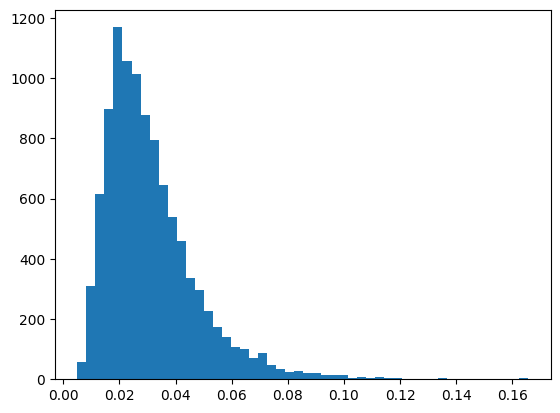

In [59]:
plt.hist(data.flatten(), bins=50)

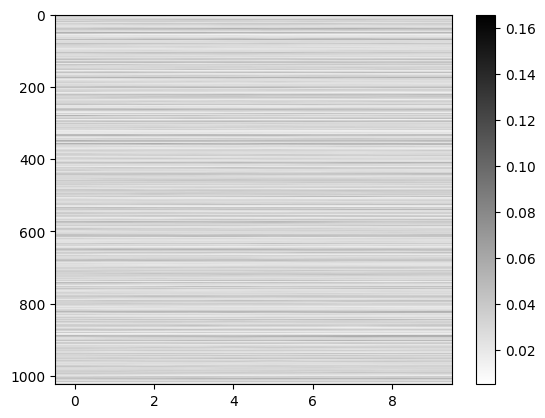

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm

data = feat_soft[..., :1024].squeeze(0).T.detach().cpu().numpy()

# Use a diverging colormap: 0 is white, negatives blue, positives red
cmap = plt.get_cmap('bwr')  # Blue-White-Red

# Center at 0 with automatic scaling on min/max
#norm = TwoSlopeNorm(vcenter=0.0, vmin=np.min(data), vmax=np.max(data))

plt.imshow(data, aspect='auto', cmap='gray_r')
plt.colorbar()

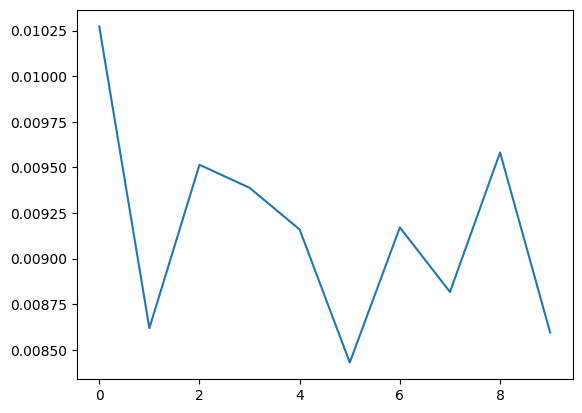

In [68]:
plt.plot(data[4])

In [50]:
feat_soft

tensor([[[ 0.0362,  0.0277,  0.0180,  ...,  0.0047,  0.1372,  0.2406],
         [ 0.0307,  0.0283,  0.0206,  ..., -0.1080, -0.4813, -0.1410],
         [ 0.0283,  0.0257,  0.0223,  ..., -0.1811, -0.2553, -0.1890],
         ...,
         [ 0.0241,  0.0245,  0.0258,  ...,  0.5326,  0.1139,  0.0867],
         [ 0.0243,  0.0221,  0.0265,  ...,  0.4380,  0.2897,  0.1250],
         [ 0.0269,  0.0229,  0.0249,  ...,  0.2954,  0.0335,  0.3176]]],
       device='cuda:0', grad_fn=<CatBackward0>)

(array([   29.,   140.,   446.,   943., 12859.,  1347.,   536.,   188.,
           50.,   358.]),
 array([-0.86406392, -0.67765754, -0.49125114, -0.30484474, -0.11843835,
         0.06796804,  0.25437444,  0.44078082,  0.62718719,  0.81359363,
         1.        ]),
 <BarContainer object of 10 artists>)

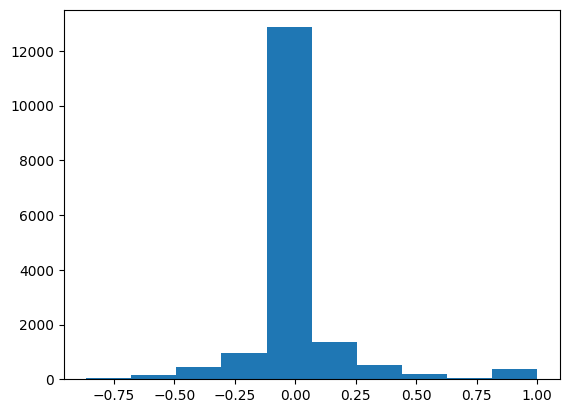

In [28]:
plt.hist(data.flatten())

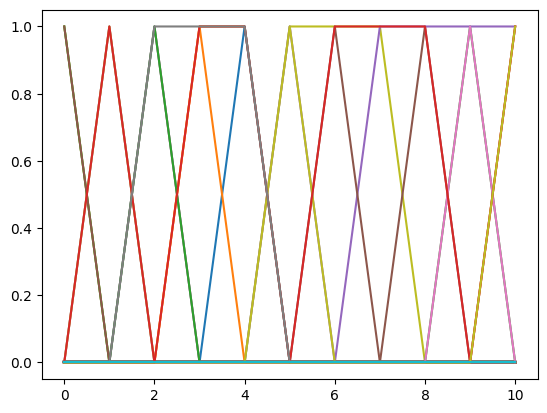

In [29]:
plt.plot(feats.squeeze(0).detach().cpu().numpy()[:, :100])
plt.show()


In [38]:
dists = wm.heads["decoder"](feats)

recon = {k: v.mode() for k, v in dists.items()}
# recon["position"], recon["velocity"] are tensors (batch, time, dim)


In [46]:
recon_all = torch.cat([recon['position'], recon['velocity']], dim=2).squeeze(0)
recon_all.shape

torch.Size([11, 5])

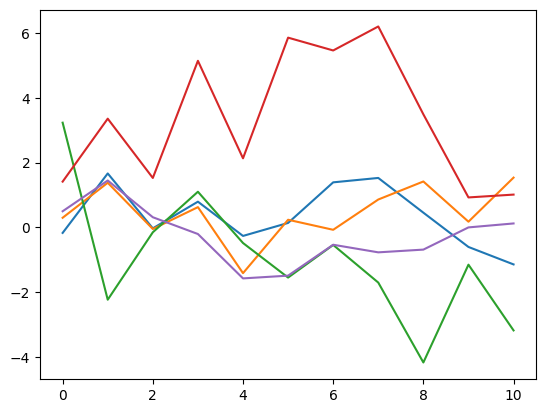

In [48]:
plt.plot(recon_all.detach().cpu().numpy()[:, :])

In [49]:
print(cfg.batch_length, cfg.imag_horizon)

64 15
